In [1]:
import random
import ast
import inspect
import instructor
import json

import openai

from pydantic import BaseModel, Field
from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from operator import add

from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage, convert_to_openai_messages, convert_to_messages

from langsmith import traceable

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Filter,
    FieldCondition,
    MatchValue,
    VectorParams,
    Distance,
    SparseVectorParams,
    Modifier,
    PayloadSchemaType,
    Document,
    PointStruct,
    Prefetch,
    FusionQuery,
    RrfQuery,
    Rrf
)

from utils.utils import get_tool_descriptions, format_ai_message

/Users/vaidasarmonas/Learning/AI-Engineering-Bootcamp/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


### Exploring Native OpenAI Tool Calling

In [2]:
from openai import OpenAI

In [3]:
client = OpenAI()

In [4]:
agent_prompt = """You are a shopping assistant that answers customer questions about products currently in stock.

## Instructions

- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When a question involves multiple products, break down the query into multiple queries for the tool call.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they are interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specfiic names or brands are missing apply broad searches.
"""

In [5]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "system",
            "content": agent_prompt
        },
        {
            "role": "user",
            "content": "I want to buy a book for my son, who is 6, and a fiction book for myself."
        }
    ],
    tools=[
        {
            "type": "function",
            "function": {
                "name": "get_formatted_item_context",
                "description": "Get the top k context, each representing an inventory item for a given query",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "query": {"type": "string", "description": "The query to get the top k context for"},
                        "top_k": {"type": "integer", "description": "The number of context items to retrieve, works best with 5 or more"}
                    },
                    "required": ["query"]
                }
            }
        }
    ],
    tool_choice="required"
)

In [6]:
response

ChatCompletion(id='chatcmpl-DX48uHe3PxNfaNn6lURChEAZLLxRZ', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_wUR3PvqyUQnICslfXJHEvm4I', function=Function(arguments='{"query": "book for 6 year old child", "top_k": 5}', name='get_formatted_item_context'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_LRcG64cIvs5JhHbDUtPb5GPf', function=Function(arguments='{"query": "fiction book", "top_k": 5}', name='get_formatted_item_context'), type='function')]))], created=1776773120, model='gpt-4.1-mini-2025-04-14', object='chat.completion', service_tier='default', system_fingerprint='fp_230182058e', usage=CompletionUsage(completion_tokens=67, prompt_tokens=307, total_tokens=374, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning

In [7]:
print(response.choices[0].message.content)

None


### Exploring LangChain Tool Calling

In [8]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

In [9]:
llm = ChatOpenAI(model="gpt-4.1-mini")

In [10]:
@tool
def dummy_tool(a: str, b: str) -> str:
    """ Concatinate a and b.

    Args:
        a: The first string to concatinate
        b: The second string to concatinate
    
    Returns:
        A concatinated string with a being first and b being second string
    """
    return f"{a} {b}"

In [11]:
llm_with_tools = llm.bind_tools(
    [dummy_tool],
    tool_choice="auto"
)

In [12]:
response = llm_with_tools.invoke("Use dummy tool to cancatinate two random words.")

In [13]:
response

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 98, 'total_tokens': 152, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_95fe14c4e4', 'id': 'chatcmpl-DX48whyIwcBjQjW0lcQjmAVlG6vho', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dafee-4882-7ce0-bc8c-619649c638dd-0', tool_calls=[{'name': 'dummy_tool', 'args': {'a': 'apple', 'b': 'banana'}, 'id': 'call_0rKvKQPa5sL4Ulw665Xrkz5s', 'type': 'tool_call'}, {'name': 'dummy_tool', 'args': {'a': 'sky', 'b': 'blue'}, 'id': 'call_PUEvuFfhXNGsHTs0AWvrnbR5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 98, 'output_tokens': 54, 'total_token

### Agent Graph with Loopback from Tools (ReAct Agent)

### Retrieval Tool

In [14]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model": "text_embedding_3_small"}
)
def get_embedding(text, model='text-embedding-3-small'):

    response = openai.embeddings.create(
        input=text,
        model=model
    )

    return response.data[0].embedding

@traceable(
    name="retrieve_data",
    run_type='retriever'
)
def retrieve_data(query, k=5):

    qdrant_client = QdrantClient(url="http://localhost:6333")
   
    query_embedding = get_embedding(query)
    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=query,
                    model="qdrant/bm25",
                ),
                using="bm25",
                limit=20
            )
        ],
        query=RrfQuery(rrf=Rrf(weights=[1,1])),
        limit=k
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []
    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):
    
    formatted_context = ""

    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return formatted_context

@tool
def get_formatted_item_context(query: str, top_k: int = 5) -> str:
    """Get the context for top k items - each item is an inventory item for a given query.

    Args:
        query: The query to get the top k items for
        top_k: The number of items and context to retrieve, works best with 5 or more

    Returns:
        A string representing context for top_k items from inventory for a given query. Information returned - IDs, average rating and description of item.
    """
    context = retrieve_data(query, top_k)

    return process_context(context)

### State and Pydantic Models for Structured Outputs

In [15]:
class RAGUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Short description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer: str = Field(description="Answer the the question")
    references: List[RAGUsedContext] = Field(description="List of items used to answer the question")

class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: Annotated[List[RAGUsedContext], add] = []

In [27]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def agent_node(state: State) -> dict:
    
    prompt = """You are a shopping assistant that answers customer questions about products currently in stock.

## Instructions

- Do not ask for clarifications. Do the best you can with the information you have in the query.
- Use the available tools to answer product questions. Do not fabricate product details.
- When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
- When a question involves multiple products, break down the query into multiple queries for the tool call.
- When describing products, include detailed specifications in bullet points.
- If tools return no relevant results, tell the customer and ask them to refine their query.
- Only answer questions about products in stock. If a question is unrelated, ask the customer to clarify what product they are interested in.
- In references, include every chunk that contributed to your answer with the chunk id and product name.
- Refer to retrieved data as "available products", never as "context".
- Try answering queries that are not precise, if specfiic names or brands are missing apply broad searches.
"""

    llm = ChatOpenAI(model="gpt-4.1-mini").bind_tools(
        [get_formatted_item_context, FinalResponse],
        tool_choice="auto"
    )

    response = llm.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""
    references = []
    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                references.extend(tool_call.get("args").get("references"))


    
    return {
        "messages": [response],
        "iteration": state.iteration + 1,
        "answer": answer,
        "final_answer": final_answer,
        "references": references
    }

In [28]:
def tool_router(state: State) -> str:
    
    if state.final_answer:
        return "end"
    
    if state.iteration > 2:
        return "end"
    
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    
    return "end"

### User Intent Router Node

In [29]:
class IntentRouterNode(BaseModel):
    question_relevant: bool
    answer: str

In [30]:
@traceable(
    name="intent_router",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State) -> dict:

    prompt_template = """You are a relevance router for a shopping assistant that answers question about products in stock.
You will be given a question and a list of context.

## Instructions

- Determine whether the question is about products, inventory or purchasing.
- Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
- Questions about store policies, personal advice, or unrelated topics are not relevant.
- If the questions is not relevant, add reason for it in the "answer" output field.

## Examples

Question: "Do you have running shoes under $100?"
Relevant: yes

Question: "What's the weather like today?"
Relevant: no - not related to products

Question: "Can you help me write an essay?"
Relevant: no - not relevant to products

Question: "Which laptop has the best battery life?"
Relevant: yes

Question: "What's your return policy?"
Relevant no - about store policy, not product information

<question>
{{ question }}
</question>
    """

    prompt = Template(prompt_template).render(
        question=state.messages[0].content
        )

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {
                "role": "system",
                "content": prompt
            }
        ],
        response_model=IntentRouterNode
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [31]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    
    return "end"

In [32]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]
tool_node = ToolNode(tools)

In [33]:
workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)
workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
graph = workflow.compile()

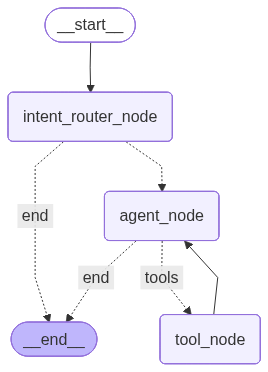

In [34]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [35]:
initial_state = {
    "messages": [HumanMessage(content="Do you have something for me? I like fiction and self help.")]
}

In [36]:
result = graph.invoke(initial_state)

In [37]:
result

{'messages': [HumanMessage(content='Do you have something for me? I like fiction and self help.', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 434, 'total_tokens': 497, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_61551e604e', 'id': 'chatcmpl-DX4EZhCK4TaKwY18kvpFeFPBLly2X', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019daff3-9e0e-7de3-b46e-c95ad3aee251-0', tool_calls=[{'name': 'get_formatted_item_context', 'args': {'query': 'fiction books', 'top_k': 3}, 'id': 'call_yjmGWMQvBtsYkvrLyb37w1uS', 'type': 'tool_call'}, {'name': 'get_formatted_item_context', 'a

In [39]:
print(result["answer"])

Here are some books you might like based on your interests in fiction and self-help:

Fiction:
- The Birds of the Air: Urban fantasy and historical fiction blended with slow-burn horror, about a girl seeking her sister amidst a mysterious underworld during the Great Depression.
- Like the Stars at Day: A fast-written fantasy fiction book full of creative ideas and story.
- The Combat Codes: A thrilling science fantasy trilogy about skilled warriors in brutal combat arenas, with martial arts mastery and intense action.

Self-Help:
- The Self-Love Workbook for Teens: A workbook designed to build confidence, eliminate self-doubt, and promote self-compassion and mental health in teenagers.
- I Forgive Myself for Forgetting Myself: A guided book with affirmations, journal prompts, and a writing plan to help overcome self-criticism and find purpose.
- Shadow Work Journal | Who Are You Truly?: A journal with 100 prompts to explore and heal your subconscious, fostering self-awareness and growt